In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [16]:
# === 1. Load data ===
df = pd.read_csv("T:/Olya/Experiments/migration_assay/in_vivo/mosaic_EC/new_analysis_2/output_Notebook_2026/plot_features.csv") 

In [17]:
# === 2. Define AV and radial mean columns ===
av_cols = [ '90th_AV', '75th_AV', 'mean_AV', '25th_AV', '10th_AV']	#'mean_AV', , 	
radial_cols = ['mean_R', '90th_R', '10th_R', '25th_R', '75th_R']
meta_cols = ['condition', 'time_point']
feature_cols = av_cols + radial_cols

In [4]:
# === 3. Extract relevant columns ===
df = df[meta_cols + feature_cols].dropna()


In [18]:
# === 4. Scale the features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])
custom_palette = {
    'Cdh5CreERT2 mTmG': '#000000',    # black
    'Cdh5CreERT2;mTmG;SMAD4FloxFlox': '#0D79F2',   # blue
    'Cdh5CreERT2;mTmG;Alk1FloxFlox': '#C333CC'    # pink   
}


In [19]:
# === 5. Run PCA ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

In [20]:
# === 6. Compute the mean PCA coords of ALL P8 samples ===
p8_center = df[df['time_point'] == 'P8'][['PC1', 'PC2']].mean().values

df['PC1_centered'] = df['PC1'] - p8_center[0]
df['PC2_centered'] = df['PC2'] - p8_center[1]

In [21]:
# === 7. Compute centroids per condition & timepoint ===
centroids = (
    df.groupby(['condition', 'time_point'])[['PC1_centered', 'PC2_centered']]
      .mean()
      .reset_index()
)

C:\Users\ooppenh\AppData\Local\Temp\ipykernel_14612\176160924.py:14: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


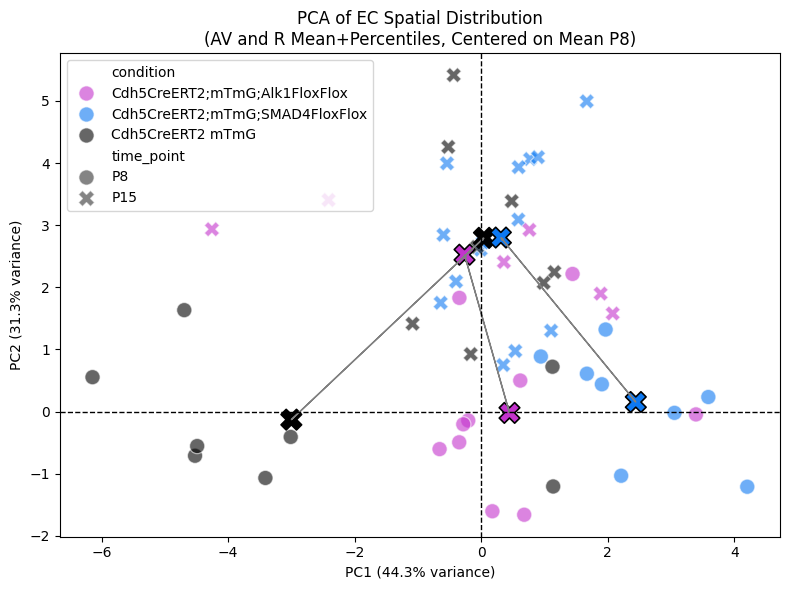

In [22]:
plt.figure(figsize=(8, 6))

# Individual samples
sns.scatterplot(
    data=df,
    x='PC1_centered', y='PC2_centered',
    hue='condition',
    style='time_point', palette=custom_palette,
    s=120,
    alpha=0.6
)

# Centroids
sns.scatterplot(
    data=centroids,
    x='PC1_centered', y='PC2_centered',
    hue='condition',
    style='time_point', palette=custom_palette,
    markers='X',
    s=220,
    legend=False,
    edgecolor='black'
)

# Arrows: P8 → P15 within each condition
for cond in centroids['condition'].unique():
    p8 = centroids[(centroids['condition'] == cond) & (centroids['time_point'] == 'P8')]
    p15 = centroids[(centroids['condition'] == cond) & (centroids['time_point'] == 'P15')]
    if not p8.empty and not p15.empty:
        plt.arrow(
            p8['PC1_centered'].values[0],
            p8['PC2_centered'].values[0],
            p15['PC1_centered'].values[0] - p8['PC1_centered'].values[0],
            p15['PC2_centered'].values[0] - p8['PC2_centered'].values[0],
            color='gray',
            width=0.003,
            head_width=0.03,
            length_includes_head=True
        )

# Reference lines: mean P8 = (0, 0)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)

plt.title("PCA of EC Spatial Distribution\n(AV and R Mean+Percentiles, Centered on Mean P8)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()

plt.savefig("pca_AV_R_mean_percentiles_centered_on_P8_140924.pdf", format='pdf')
plt.show()

In [67]:
!pip install scikit-bio


   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   ------ --------------------------------- 1.0/6.4 MB 10.1 MB/s eta 0:00:01
   ------------- -------------------------- 2.1/6.4 MB 4.9 MB/s eta 0:00:01
   ---------------------- ----------------- 3.7/6.4 MB 5.7 MB/s eta 0:00:01
   -------------------------------- ------- 5.2/6.4 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------  6.3/6.4 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------- 6.4/6.4 MB 6.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------- ----------------------- 5.0/11.9 MB 23.2 MB/s eta 0:00:01
   ------------------------------- -------- 9.4/11.9 MB 22.6 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 18.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ------------------------------------ --- 2.6/2.9 MB 21.6 MB/s eta 0:00:01
   --------------------

In [23]:
#PERMANOVA on both PC1+PC2
from skbio.stats.distance import permanova
from skbio.stats.distance import DistanceMatrix
from scipy.spatial.distance import pdist, squareform

# Create 2D distance matrix from PCA coords
coords = df[['PC1_centered', 'PC2_centered']].values
dmatrix = DistanceMatrix(squareform(pdist(coords)), ids=df.index.astype(str))

# Define grouping labels
df['group'] = df['condition'] + '_' + df['time_point'].astype(str)
grouping = df['group']
grouping.index = df.index.astype(str)  # Ensure matching string indices

# Run PERMANOVA
results = permanova(dmatrix, grouping=grouping, permutations=999)
print(results)
results.to_csv("AV_R_mean_percentiles_PERMANOVA_summary.csv", index=False)


method name               PERMANOVA
test statistic name        pseudo-F
sample size                      54
number of groups                  6
test statistic            11.821687
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object


In [24]:
#Vector analysis
import numpy as np

vector_data = []

# Loop over genotypes
for cond in centroids['condition'].unique():
    p8 = centroids[(centroids['condition'] == cond) & (centroids['time_point'] == 'P8')]
    p15 = centroids[(centroids['condition'] == cond) & (centroids['time_point'] == 'P15')]

    if not p8.empty and not p15.empty:
        delta_pc1 = p15['PC1_centered'].values[0] - p8['PC1_centered'].values[0]
        delta_pc2 = p15['PC2_centered'].values[0] - p8['PC2_centered'].values[0]
        magnitude = np.sqrt(delta_pc1**2 + delta_pc2**2)
        angle_deg = np.degrees(np.arctan2(delta_pc2, delta_pc1))

        vector_data.append({
            'condition': cond,
            'ΔPC1': delta_pc1,
            'ΔPC2': delta_pc2,
            'magnitude': magnitude,
            'angle_deg': angle_deg
        })

df_vectors = pd.DataFrame(vector_data)
print(df_vectors)
df_vectors.to_csv("AV_R_mean_percentiles_vector_shifts_summary.csv", index=False)


                        condition      ΔPC1      ΔPC2  magnitude   angle_deg
0                Cdh5CreERT2 mTmG  3.045088  2.925180   4.222468   43.849416
1   Cdh5CreERT2;mTmG;Alk1FloxFlox -0.711003  2.545346   2.642784  105.606891
2  Cdh5CreERT2;mTmG;SMAD4FloxFlox -2.133082  2.646894   3.399424  128.864689


In [26]:
loadings = pd.DataFrame(pca.components_, columns=feature_cols, index=['PC1', 'PC2'])
print(loadings.T.sort_values(by='PC1', ascending=False))  # or by PC2
loadings.to_csv("PCA_component_loadings_AV_R_mean_percentiles.csv", index=False)

              PC1       PC2
mean_R   0.462195  0.122352
25th_R   0.448023  0.054316
75th_R   0.424681  0.155034
10th_R   0.399554  0.104131
90th_R   0.382680  0.241364
10th_AV -0.018494  0.069392
25th_AV -0.065698  0.439303
mean_AV -0.159671  0.521619
75th_AV -0.165127  0.491743
90th_AV -0.204426  0.421004


In [28]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Make sure collection_time is treated as categorical
df['time_point'] = df['time_point'].astype(str)

model = ols('PC2_centered ~ C(condition) * C(time_point)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

anova_table.to_csv("PC2_ANOVA_AV-R.csv", index=False)

                               sum_sq    df          F        PR(>F)
C(condition)                 0.375693   2.0   0.134123  8.748086e-01
C(time_point)               93.882612   1.0  67.032710  1.149165e-10
C(condition):C(time_point)   0.306676   2.0   0.109484  8.965195e-01
Residual                    67.226364  48.0        NaN           NaN
